In [1]:
import os
import subprocess

target_dir = "/data/projects/nckf/reanalysis/EN4/updated/"
os.makedirs(target_dir, exist_ok=True)
os.chdir(target_dir)

base_url = "http://www.metoffice.gov.uk/hadobs/en4/data/en4-2-1/EN.4.2.2"

for year in range(1900, 2026):
    fname = f"EN.4.2.2.analyses.g10.{year}.zip"
    url = f"{base_url}/{fname}"
    print(f"⬇️ Downloading {year} ...")
    subprocess.run(["wget", "-q", "-O", fname, url])
    subprocess.run(["unzip", "-o", fname], stdout=subprocess.DEVNULL)
    os.remove(fname)

print("✅ All EN4 analysis files downloaded and extracted.")


⬇️ Downloading 1900 ...
⬇️ Downloading 1901 ...
⬇️ Downloading 1902 ...
⬇️ Downloading 1903 ...
⬇️ Downloading 1904 ...
⬇️ Downloading 1905 ...
⬇️ Downloading 1906 ...
⬇️ Downloading 1907 ...
⬇️ Downloading 1908 ...
⬇️ Downloading 1909 ...
⬇️ Downloading 1910 ...
⬇️ Downloading 1911 ...
⬇️ Downloading 1912 ...
⬇️ Downloading 1913 ...
⬇️ Downloading 1914 ...
⬇️ Downloading 1915 ...
⬇️ Downloading 1916 ...
⬇️ Downloading 1917 ...
⬇️ Downloading 1918 ...
⬇️ Downloading 1919 ...
⬇️ Downloading 1920 ...
⬇️ Downloading 1921 ...
⬇️ Downloading 1922 ...
⬇️ Downloading 1923 ...
⬇️ Downloading 1924 ...
⬇️ Downloading 1925 ...
⬇️ Downloading 1926 ...
⬇️ Downloading 1927 ...
⬇️ Downloading 1928 ...
⬇️ Downloading 1929 ...
⬇️ Downloading 1930 ...
⬇️ Downloading 1931 ...
⬇️ Downloading 1932 ...
⬇️ Downloading 1933 ...
⬇️ Downloading 1934 ...
⬇️ Downloading 1935 ...
⬇️ Downloading 1936 ...
⬇️ Downloading 1937 ...
⬇️ Downloading 1938 ...
⬇️ Downloading 1939 ...
⬇️ Downloading 1940 ...
⬇️ Downloading 1

  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of EN.4.2.2.analyses.g10.2022.zip or
        EN.4.2.2.analyses.g10.2022.zip.zip, and cannot find EN.4.2.2.analyses.g10.2022.zip.ZIP, period.
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of EN.4.2.2.analyses.g10.2023.zip or
        EN.4.2.2.analyses.g10.2023.zip.zip, and cannot find EN.4.2.2.analyses.g10.2023.zip.ZIP, period.


⬇️ Downloading 2024 ...


  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of EN.4.2.2.analyses.g10.2024.zip or
        EN.4.2.2.analyses.g10.2024.zip.zip, and cannot find EN.4.2.2.analyses.g10.2024.zip.ZIP, period.


⬇️ Downloading 2025 ...
✅ All EN4 analysis files downloaded and extracted.


  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of EN.4.2.2.analyses.g10.2025.zip or
        EN.4.2.2.analyses.g10.2025.zip.zip, and cannot find EN.4.2.2.analyses.g10.2025.zip.ZIP, period.


In [15]:
import xarray as xr
import numpy as np
import glob
import os

# =========================
# CONFIG
# =========================
indir = "/data/projects/nckf/reanalyses/EN4/updated/"
outpath = "/data/projects/nckf/reanalyses/EN4/updated/EN4_yearly_SST_1900_2025.nc"

files = sorted(glob.glob(os.path.join(indir, "EN.4.2.2.f.analysis.g10.*.nc")))
print(f"Found {len(files)} monthly files")

# =========================
# LOAD MONTHLY SST
# =========================
sst_list = []
year_list = []

for f in files:
    try:
        ds = xr.open_dataset(f, engine="netcdf4", decode_times=True)

        # Extract SST = temperature at depth=0
        sst = ds["temperature"].isel(depth=0)

        # Convert from Kelvin to Celsius
        sst = sst - 273.15

        # Extract year
        year = sst["time"].dt.year.values[0]

        sst_list.append(sst)
        year_list.append(year)

    except Exception as e:
        print(f"⚠️ Skipping corrupt or unreadable file: {f}")
        print("   ", e)
        continue

print("Loaded monthly SST:", len(sst_list))

# =========================
# COMBINE → YEARLY MEAN
# =========================
sst_monthly = xr.concat(sst_list, dim="time")

# Compute mean per year
sst_yearly = sst_monthly.groupby("time.year").mean("time")

# Rename dimension
sst_yearly = sst_yearly.rename({"year": "time"})
sst_yearly = sst_yearly.assign_coords(time=sst_yearly["time"])

print("Final yearly dataset:")
print(sst_yearly)

# =========================
# SAVE
# =========================
sst_yearly.to_netcdf(outpath)
print(f"✅ Saved yearly SST file to:\n{outpath}")




Found 1458 monthly files
Loaded monthly SST: 1458
Final yearly dataset:
<xarray.DataArray 'temperature' (time: 122, lat: 173, lon: 360)> Size: 61MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-1.74173682, -1.74778394, -1.75039241, ..., -1.73830606,
         -1.74047663, -1.74176299],
        [-1.57533425, -1.57900325, -1.58074644, ..., -1.57125207,
         -1.57282572, -1.57434594],
        [-1.53319883, -1.53462181, -1.53559695, ..., -1.53143546,
         -1.53212683, -1.53289223]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,

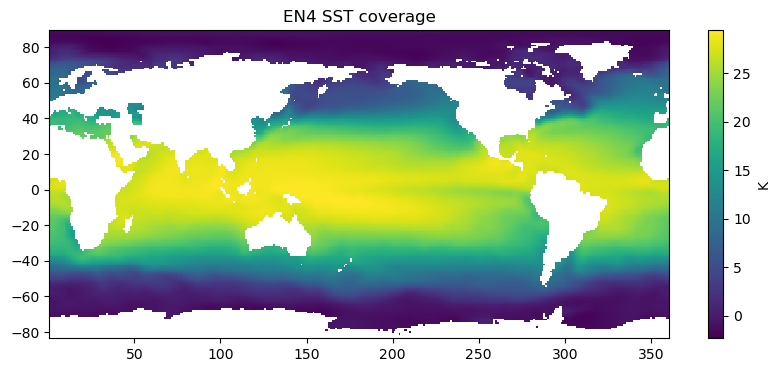

In [18]:
import xarray as xr
import matplotlib.pyplot as plt

en4 = xr.open_dataset("/data/projects/nckf/reanalyses/EN4/updated/EN4_yearly_SST_1900_2025.nc")

# take one year for plotting
sst = en4["temperature"].isel(time=0)  # first year

plt.figure(figsize=(10,4))
plt.pcolormesh(en4["lon"], en4["lat"], sst, shading="auto")
plt.title("EN4 SST coverage")
plt.colorbar(label="K")
plt.show()


In [32]:
import xarray as xr
import numpy as np

# Example first monthly file (change later to open_mfdataset)
path = "/data/projects/nckf/reanalyses/EN4/updated/EN.4.2.2.f.analysis.g10.190001.nc"

ds = xr.open_dataset(path)
sst = ds["temperature"].isel(depth=0)   # surface layer


In [33]:
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree

# ---------------- SOURCE: tripolar subbasin mask ----------------
sub = xr.open_dataset("/data/users/mde/FREJA/subbasins.nc")
atl_src = sub["atlmsk"].values
lat_src = sub["nav_lat"].values
lon_src = sub["nav_lon"].values % 360

# flatten and keep valid points
mask_flat = atl_src.ravel()
lat_flat = lat_src.ravel()
lon_flat = lon_src.ravel()
good = np.isfinite(mask_flat)
mask_flat = mask_flat[good]
lat_flat = lat_flat[good]
lon_flat = lon_flat[good]

# convert to 3D unit sphere coords
def sph2cart(lon, lat):
    lon_r = np.deg2rad(lon)
    lat_r = np.deg2rad(lat)
    x = np.cos(lat_r) * np.cos(lon_r)
    y = np.cos(lat_r) * np.sin(lon_r)
    z = np.sin(lat_r)
    return np.column_stack([x, y, z])

src_xyz = sph2cart(lon_flat, lat_flat)
tree = cKDTree(src_xyz)

# ---------------- TARGET: EN4 grid ----------------
ds_en4 = xr.open_dataset(path)  # any EN4 file for coordinates
lat_t = ds_en4["lat"].values
lon_t = ds_en4["lon"].values % 360
lon2, lat2 = np.meshgrid(lon_t, lat_t)

tgt_xyz = sph2cart(lon2.ravel(), lat2.ravel())
_, idx = tree.query(tgt_xyz)

mask_en4 = (mask_flat[idx].reshape(lon2.shape) >= 0.5).astype(np.int8)

# Save mask
xr.DataArray(mask_en4, dims=("lat","lon"),
             coords={"lat": lat_t, "lon": lon_t},
             name="atlmsk").to_netcdf(
    "/data/users/frekle/atlantic_mask_en4.nc"
)


In [35]:
mask = xr.open_dataarray("/data/users/frekle/atlantic_mask_en4.nc")

sst_masked = sst * mask

sst_mean = sst_masked.mean(dim=("lat","lon"), skipna=True)
print(sst_mean.values)

[79.7520657]


In [47]:
import xarray as xr
import numpy as np

# ==========================================================
# FILE PATHS
# ==========================================================
EN4_FILE = "/data/projects/nckf/reanalyses/EN4/updated/EN4_yearly_SST_1900_2025.nc"
EN4_MASK = "/data/projects/nckf/frekle/mask_bool_EN4.nc"
OUT_FILE = "/dmidata/projects/nckf/frekle/obs_data/EN4_SST_Atlantic_masked.nc"

# ==========================================================
# LOAD EN4 SST (already surface-only)
# ==========================================================
ds = xr.open_dataset(EN4_FILE)
sst = ds["temperature"]    # (time, lat, lon)

print("EN4 SST shape:", sst.shape)

# ==========================================================
# LOAD ATLANTIC MASK (lat, lon)
# ==========================================================
mask = xr.open_dataset(EN4_MASK)["atlmsk"]

print("Mask shape:", mask.shape)

# Safety check
if mask.shape != sst.isel(time=0).shape:
    raise ValueError("❌ Mask grid does not match EN4 grid!")

# ==========================================================
# APPLY MASK (multiply → NaNs outside Atlantic)
# ==========================================================
sst_masked = sst * mask

# Clean up: force non-Atlantic cells to NaN
sst_masked = sst_masked.where(mask == 1)

# ==========================================================
# BUILD NEW DATASET
# ==========================================================
ds_masked = xr.Dataset(
    {"sst": sst_masked},
    coords={"time": ds["time"], "lat": ds["lat"], "lon": ds["lon"]},
)

ds_masked["sst"].attrs = ds["temperature"].attrs
ds_masked["sst"].attrs["note"] = "Masked to Atlantic using EN4 mask"

# ==========================================================
# SAVE
# ==========================================================
ds_masked.to_netcdf(OUT_FILE)

print("✅ Saved masked EN4 SST dataset to:")
print(OUT_FILE)





EN4 SST shape: (122, 173, 360)
Mask shape: (173, 360)
✅ Saved masked EN4 SST dataset to:
/dmidata/projects/nckf/frekle/obs_data/EN4_SST_Atlantic_masked.nc


In [49]:
import xarray as xr

path = "/dmidata/projects/nckf/frekle/obs_data/EN4_SST_Atlantic_masked.nc"
ds = xr.open_dataset(path)

print(ds)
print("Dimensions:", ds.dims)
print("Coords:", ds.coords)

if "time" in ds:
    print("time dtype:", ds["time"].dtype)
    print("first few times:", ds["time"].values[:5])
else:
    print("⚠ No time dimension!")


<xarray.Dataset> Size: 61MB
Dimensions:  (lat: 173, lon: 360, time: 122)
Coordinates:
    depth    float32 4B ...
  * lat      (lat) float32 692B -83.0 -82.0 -81.0 -80.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * time     (time) int64 976B 1900 1901 1902 1903 1904 ... 2018 2019 2020 2021
Data variables:
    sst      (time, lat, lon) float64 61MB ...
Dimensions: FrozenMappingWarningOnValuesAccess({'lat': 173, 'lon': 360, 'time': 122})
Coords: Coordinates:
    depth    float32 4B ...
  * lat      (lat) float32 692B -83.0 -82.0 -81.0 -80.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * time     (time) int64 976B 1900 1901 1902 1903 1904 ... 2018 2019 2020 2021
time dtype: int64
first few times: [1900 1901 1902 1903 1904]


Loading EN4 masked SST…
EN4 years covered (non-NaN): [1900. 1901. 1902. 1903. 1904. 1905. 1906. 1907. 1908. 1909. 1910. 1911.
 1912. 1913. 1914. 1915. 1916. 1917. 1918. 1919. 1920. 1921. 1922. 1923.
 1924. 1925. 1926. 1927. 1928. 1929. 1930. 1931. 1932. 1933. 1934. 1935.
 1936. 1937. 1938. 1939. 1940. 1941. 1942. 1943. 1944. 1945. 1946. 1947.
 1948. 1949. 1950. 1951. 1952. 1953. 1954. 1955. 1956. 1957. 1958. 1959.
 1960. 1961. 1962. 1963. 1964. 1965. 1966. 1967. 1968. 1969. 1970. 1971.
 1972. 1973. 1974. 1975. 1976. 1977. 1978. 1979. 1980. 1981. 1982. 1983.
 1984. 1985. 1986. 1987. 1988. 1989. 1990. 1991. 1992. 1993. 1994. 1995.
 1996. 1997. 1998. 1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007.
 2008. 2009. 2010. 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018. 2019.
 2020. 2021.]

=== LOADING MODELS ===
EC-Earth3: found 22 members
  -> /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r10i1p1f1.nc
  -> /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thet

/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


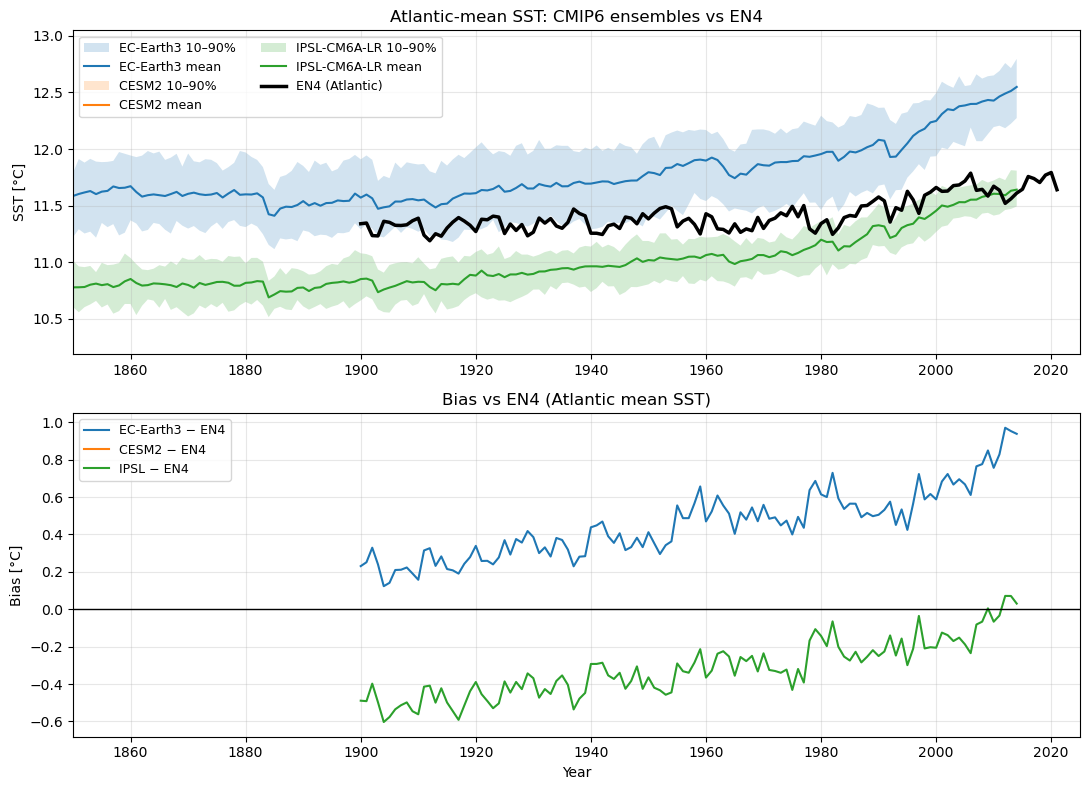

In [52]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt

# ======================================================
# PATHS
# ======================================================
EN4_FILE = "/data/projects/nckf/frekle/obs_data/EN4_SST_Atlantic_masked.nc"

EC_PATTERN   = "/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r*i1p1f1.nc"
CESM_PATTERN = "/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/masked/thetao_masked_r*i1p1f1.nc"
IPSL_PATTERN = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao/thetao_masked_r*i1p1f1.nc"

FULL_YEARS = np.arange(1850, 2026)  # plotting frame


# ======================================================
# HELPER: load model masked files → annual Atlantic mean SST
# ======================================================
def model_sst_timeseries(file_pattern, name="MODEL"):
    """
    Parameters
    ----------
    file_pattern : str
        Glob for masked thetao files for a single model.
    Returns
    -------
    DataArray (member, year) in °C
    """
    files = sorted(glob.glob(file_pattern))
    if not files:
        raise ValueError(f"No files found for pattern {file_pattern}")
    print(f"{name}: found {len(files)} members")

    member_ts = []

    for f in files:
        print(f"  -> {f}")
        ds = xr.open_dataset(f)

        # ---- pick thetao variable ----
        if "thetao" in ds:
            da3d = ds["thetao"]
        else:
            # fall-back: first variable with 'time' in dims
            cand = [v for v in ds.data_vars if "time" in ds[v].dims]
            if not cand:
                raise ValueError(f"No 3D variable with time found in {f}")
            da3d = ds[cand[0]]

        # ---- find depth dimension ----
        depth_dim = None
        for cand in ["olevel", "lev", "depth", "z_t", "z", "zl"]:
            if cand in da3d.dims:
                depth_dim = cand
                break
        if depth_dim is None:
            raise ValueError(f"No depth dim found in {f}, dims={da3d.dims}")

        # ---- surface layer ----
        sst = da3d.isel({depth_dim: 0})

        # ---- make sure in °C (quick sanity check) ----
        mval = float(sst.mean().values)
        if mval > 150:  # probably Kelvin
            sst = sst - 273.15

        # ---- regional (masked) spatial mean ----
        space_dims = [d for d in sst.dims if d != "time"]
        sst_spatial = sst.mean(dim=space_dims, skipna=True)  # 1D time

        # ---- yearly mean ----
        time = sst_spatial["time"]
        if np.issubdtype(time.dtype, np.datetime64):
            years = time.dt.year
            sst_year = sst_spatial.groupby(years).mean("time")
            # xarray may already have replaced "time" with "year"
            if "time" in sst_year.dims:
                sst_year = sst_year.rename({"time": "year"})

            # ensure we have a proper year coordinate
            sst_year = sst_year.assign_coords(year=("year", np.unique(years.values)))

        else:
            # already annual
            if "time" in sst_spatial.dims:
                sst_year = sst_spatial.rename({"time": "year"})
            else:
                sst_year = sst_spatial

        member_ts.append(sst_year)

        ds.close()

    # stack members
    da = xr.concat(member_ts, dim="member")
    da = da.assign_coords(member=np.arange(1, len(member_ts) + 1))

    # reindex to full target years (1850–2025) with NaN where no data
    da = da.reindex(year=FULL_YEARS)

    return da  # (member, year)


# ======================================================
# EN4: annual Atlantic-mean SST from masked file
# ======================================================
print("Loading EN4 masked SST…")
en4_ds = xr.open_dataset(EN4_FILE)
# expect sst(time, lat, lon) where "time" is already years (int)
en4_sst = en4_ds["sst"]

# rename time → year if needed
if "time" in en4_sst.dims:
    en4_sst = en4_sst.rename({"time": "year"})

# spatial mean over Atlantic region
space_dims_en4 = [d for d in en4_sst.dims if d != "year"]
en4_mean = en4_sst.mean(dim=space_dims_en4, skipna=True)  # (year)

# sanity: convert from K if needed
if float(en4_mean.mean()) > 150:
    en4_mean = en4_mean - 273.15

# reindex to same full year axis (will pad with NaN outside data range)
en4_mean = en4_mean.reindex(year=FULL_YEARS)

print("EN4 years covered (non-NaN):",
      en4_mean["year"].where(~np.isnan(en4_mean), drop=True).values)


# ======================================================
# MODELS: annual Atlantic-mean SST per member
# ======================================================
print("\n=== LOADING MODELS ===")
ec_sst   = model_sst_timeseries(EC_PATTERN,   name="EC-Earth3")  # (member,year)
cesm_sst = model_sst_timeseries(CESM_PATTERN, name="CESM2")
ipsl_sst = model_sst_timeseries(IPSL_PATTERN, name="IPSL-CM6A-LR")

# ensemble mean & spread
def describe_ensemble(da):
    mean = da.mean("member")
    p10  = da.quantile(0.10, dim="member")
    p90  = da.quantile(0.90, dim="member")
    return mean, p10, p90

ec_mean, ec_p10, ec_p90     = describe_ensemble(ec_sst)
cesm_mean, cesm_p10, cesm_p90 = describe_ensemble(cesm_sst)
ipsl_mean, ipsl_p10, ipsl_p90 = describe_ensemble(ipsl_sst)

# ======================================================
# BIASES: (model mean − EN4)
# Only where EN4 is available
# ======================================================
valid_en4 = ~np.isnan(en4_mean)
years_bias = en4_mean["year"].where(valid_en4, drop=True)

def model_bias(model_mean):
    m = model_mean.sel(year=years_bias)
    e = en4_mean.sel(year=years_bias)
    return m - e

ec_bias   = model_bias(ec_mean)
cesm_bias = model_bias(cesm_mean)
ipsl_bias = model_bias(ipsl_mean)

# ======================================================
# PLOTTING
# ======================================================
plt.figure(figsize=(11, 8))

# ----------------- (1) Time evolution -----------------
ax1 = plt.subplot(2,1,1)

# EC-Earth3
ax1.fill_between(FULL_YEARS, ec_p10, ec_p90,
                 alpha=0.2, label="EC-Earth3 10–90%")
ax1.plot(FULL_YEARS, ec_mean, label="EC-Earth3 mean")

# CESM2
ax1.fill_between(FULL_YEARS, cesm_p10, cesm_p90,
                 alpha=0.2, label="CESM2 10–90%")
ax1.plot(FULL_YEARS, cesm_mean, label="CESM2 mean")

# IPSL
ax1.fill_between(FULL_YEARS, ipsl_p10, ipsl_p90,
                 alpha=0.2, label="IPSL-CM6A-LR 10–90%")
ax1.plot(FULL_YEARS, ipsl_mean, label="IPSL-CM6A-LR mean")

# EN4 (from ~1900)
ax1.plot(FULL_YEARS, en4_mean, color="k", lw=2.5, label="EN4 (Atlantic)")

ax1.set_xlim(1850, 2025)
ax1.set_ylabel("SST [°C]")
ax1.set_title("Atlantic-mean SST: CMIP6 ensembles vs EN4")
ax1.grid(True, alpha=0.3)
ax1.legend(ncol=2, fontsize=9)

# make y-axis a bit tight around data
all_series = [
    ec_mean, cesm_mean, ipsl_mean,
    en4_mean
]
ymin = min(float(a.min()) for a in all_series if np.isfinite(a.min()))
ymax = max(float(a.max()) for a in all_series if np.isfinite(a.max()))
pad = 0.5
ax1.set_ylim(ymin - pad, ymax + pad)

# ----------------- (2) Biases -----------------
ax2 = plt.subplot(2,1,2, sharex=ax1)

ax2.plot(years_bias, ec_bias,   label="EC-Earth3 − EN4")
ax2.plot(years_bias, cesm_bias, label="CESM2 − EN4")
ax2.plot(years_bias, ipsl_bias, label="IPSL − EN4")

ax2.axhline(0, color="k", lw=1)
ax2.set_xlim(1850, 2025)
ax2.set_ylabel("Bias [°C]")
ax2.set_xlabel("Year")
ax2.set_title("Bias vs EN4 (Atlantic mean SST)")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()



Loading EN4 masked SST…
EN4 non-NaN years: [1900. 1901. 1902. 1903. 1904. 1905. 1906. 1907. 1908. 1909. 1910. 1911.
 1912. 1913. 1914. 1915. 1916. 1917. 1918. 1919. 1920. 1921. 1922. 1923.
 1924. 1925. 1926. 1927. 1928. 1929. 1930. 1931. 1932. 1933. 1934. 1935.
 1936. 1937. 1938. 1939. 1940. 1941. 1942. 1943. 1944. 1945. 1946. 1947.
 1948. 1949. 1950. 1951. 1952. 1953. 1954. 1955. 1956. 1957. 1958. 1959.
 1960. 1961. 1962. 1963. 1964. 1965. 1966. 1967. 1968. 1969. 1970. 1971.
 1972. 1973. 1974. 1975. 1976. 1977. 1978. 1979. 1980. 1981. 1982. 1983.
 1984. 1985. 1986. 1987. 1988. 1989. 1990. 1991. 1992. 1993. 1994. 1995.
 1996. 1997. 1998. 1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007.
 2008. 2009. 2010. 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018. 2019.
 2020. 2021.]

=== LOADING MODELS ===
EC-Earth3: found 22 members
 → /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r10i1p1f1.nc
 → /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r11

/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


ValueError: zero-size array to reduction operation minimum which has no identity

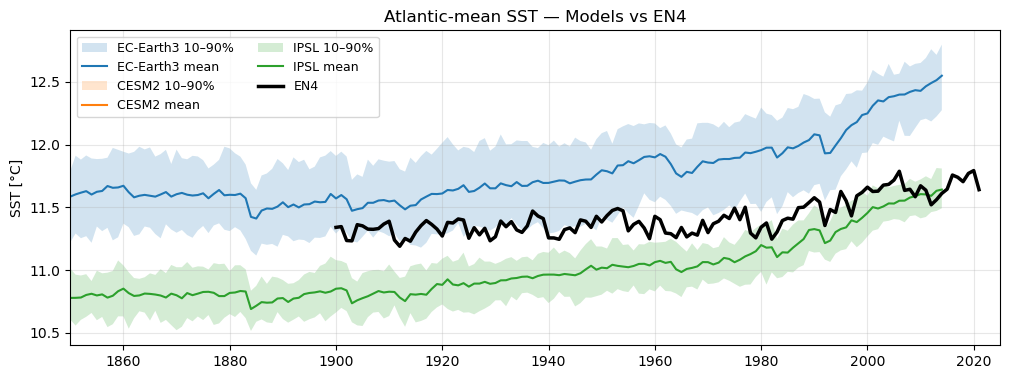

In [9]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt

# ======================================================
# PATHS
# ======================================================
EN4_FILE = "/data/projects/nckf/frekle/obs_data/EN4_SST_Atlantic_masked.nc"

EC_PATTERN   = "/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r*i1p1f1.nc"
CESM_PATTERN = "/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/masked/thetao_masked_r*i1p1f1.nc"
IPSL_PATTERN = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao/thetao_masked_r*i1p1f1.nc"

FULL_YEARS = np.arange(1850, 2026)


# ======================================================
# HELPER: extract annual SST from masked model file
# ======================================================
def load_model_member(path):
    ds = xr.open_dataset(path)

    # ---- find variable ----
    if "thetao" in ds:
        da3d = ds["thetao"]
    else:
        cand = [v for v in ds.data_vars if "time" in ds[v].dims]
        da3d = ds[cand[0]]

    # ---- find depth dimension ----
    for cand in ["olevel", "lev", "depth", "z_t", "z", "zl"]:
        if cand in da3d.dims:
            depth_dim = cand
            break

    # convert CESM lev from cm → m if needed (not needed for temperature)
    # select surface
    sst = da3d.isel({depth_dim: 0})

    # ---- Convert K → °C if needed ----
    mval = float(sst.mean().values)
    if mval > 150:
        sst = sst - 273.15

    # ---- spatial mean over masked region ----
    space_dims = [d for d in sst.dims if d != "time"]
    sst_spatial = sst.mean(dim=space_dims, skipna=True)

    # ---- annual mean ----
    time = sst_spatial["time"]

    if np.issubdtype(time.dtype, np.datetime64):
        years = time.dt.year
        sst_year = sst_spatial.groupby(years).mean("time")
        if "time" in sst_year.dims:
            sst_year = sst_year.rename({"time": "year"})
        sst_year = sst_year.assign_coords(year=("year", np.unique(years.values)))
    else:
        # already annual
        if "time" in sst_spatial.dims:
            sst_year = sst_spatial.rename({"time": "year"})
        else:
            sst_year = sst_spatial

    ds.close()
    return sst_year


# ======================================================
# HELPER: load all members for one model
# ======================================================
def model_sst_timeseries(pattern, name="MODEL"):
    files = sorted(glob.glob(pattern))
    if not files:
        raise ValueError(f"No files found: {pattern}")
    print(f"{name}: found {len(files)} members")

    members = []

    for f in files:
        print(f" → {f}")
        ts = load_model_member(f)
        members.append(ts)

    da = xr.concat(members, dim="member")
    da = da.assign_coords(member=np.arange(1, len(members) + 1))

    da = da.reindex(year=FULL_YEARS)

    return da


# ======================================================
# EN4 LOADING
# ======================================================
print("\nLoading EN4 masked SST…")
en4 = xr.open_dataset(EN4_FILE)["sst"]

if "time" in en4.dims:
    en4 = en4.rename({"time": "year"})

space_dims = [d for d in en4.dims if d != "year"]
en4_mean = en4.mean(dim=space_dims, skipna=True)

if float(en4_mean.mean()) > 150:
    en4_mean = en4_mean - 273.15

en4_mean = en4_mean.reindex(year=FULL_YEARS)

print("EN4 non-NaN years:",
      en4_mean["year"].where(~np.isnan(en4_mean), drop=True).values)


# ======================================================
# LOAD MODELS
# ======================================================
print("\n=== LOADING MODELS ===")
ec_sst   = model_sst_timeseries(EC_PATTERN,   "EC-Earth3")
cesm_sst = model_sst_timeseries(CESM_PATTERN, "CESM2")
ipsl_sst = model_sst_timeseries(IPSL_PATTERN, "IPSL-CM6A-LR")


# ======================================================
# ENSEMBLE STATISTICS
# ======================================================
def describe_ensemble(da):
    return (
        da.mean("member"),
        da.quantile(0.10, dim="member"),
        da.quantile(0.90, dim="member")
    )

ec_mean, ec_p10, ec_p90 = describe_ensemble(ec_sst)
cesm_mean, cesm_p10, cesm_p90 = describe_ensemble(cesm_sst)
ipsl_mean, ipsl_p10, ipsl_p90 = describe_ensemble(ipsl_sst)


# ======================================================
# BIASES (only where EN4 exists)
# ======================================================
valid_en4 = ~np.isnan(en4_mean)
years_bias = en4_mean["year"].where(valid_en4, drop=True)

def model_bias(model_mean):
    return model_mean.sel(year=years_bias) - en4_mean.sel(year=years_bias)

ec_bias   = model_bias(ec_mean)
cesm_bias = model_bias(cesm_mean)
ipsl_bias = model_bias(ipsl_mean)


# ======================================================
# PLOTTING
# ======================================================
plt.figure(figsize=(12, 9))

# -----------------(1) TIME EVOLUTION -----------------
ax1 = plt.subplot(2,1,1)

# EC-Earth3
ax1.fill_between(ec_p10["year"], ec_p10, ec_p90, alpha=0.20, label="EC-Earth3 10–90%")
ax1.plot(ec_mean["year"], ec_mean, label="EC-Earth3 mean")

# CESM2
ax1.fill_between(cesm_p10["year"], cesm_p10, cesm_p90, alpha=0.20, label="CESM2 10–90%")
ax1.plot(cesm_mean["year"], cesm_mean, label="CESM2 mean")

# IPSL
ax1.fill_between(ipsl_p10["year"], ipsl_p10, ipsl_p90, alpha=0.20, label="IPSL 10–90%")
ax1.plot(ipsl_mean["year"], ipsl_mean, label="IPSL mean")

# EN4
ax1.plot(en4_mean["year"], en4_mean, color="k", lw=2.5, label="EN4")

ax1.set_xlim(1850, 2025)
ax1.set_ylabel("SST [°C]")
ax1.set_title("Atlantic-mean SST — Models vs EN4")
ax1.grid(True, alpha=0.3)
ax1.legend(ncol=2, fontsize=9)

# tighten y-limits
all_series = [ec_mean, cesm_mean, ipsl_mean, en4_mean]

def finite_bounds(da):
    arr = da.values
    arr = arr[np.isfinite(arr)]
    return arr.min(), arr.max()

mins, maxs = zip(*(finite_bounds(a) for a in all_series))
ax1.set_ylim(min(mins)-0.5, max(maxs)+0.5)

# -----------------(2) BIAS -----------------
ax2 = plt.subplot(2,1,2, sharex=ax1)

ax2.plot(ec_bias["year"], ec_bias, label="EC-Earth3 – EN4")
ax2.plot(cesm_bias["year"], cesm_bias, label="CESM2 – EN4")
ax2.plot(ipsl_bias["year"], ipsl_bias, label="IPSL – EN4")

ax2.axhline(0, color="k", lw=1)
ax2.set_xlim(1850, 2025)
ax2.set_ylabel("Bias [°C]")
ax2.set_xlabel("Year")
ax2.set_title("Model Bias vs EN4 (Atlantic SST)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


EC-Earth3: found 6 weakening members
  -> /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r11i1p1f1.nc
  -> /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r19i1p1f1.nc
  -> /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r1i1p1f1.nc
  -> /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r24i1p1f1.nc
  -> /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r7i1p1f1.nc
  -> /data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r8i1p1f1.nc
IPSL: found 6 weakening members
  -> /data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao/thetao_masked_r11i1p1f1.nc
  -> /data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao/thetao_masked_r13i1p1f1.nc
  -> /data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao/thetao_masked_r16i1p1f1.nc
  -> /data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao/thetao_masked_r20i1p1f1.nc
  -> /data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A

/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


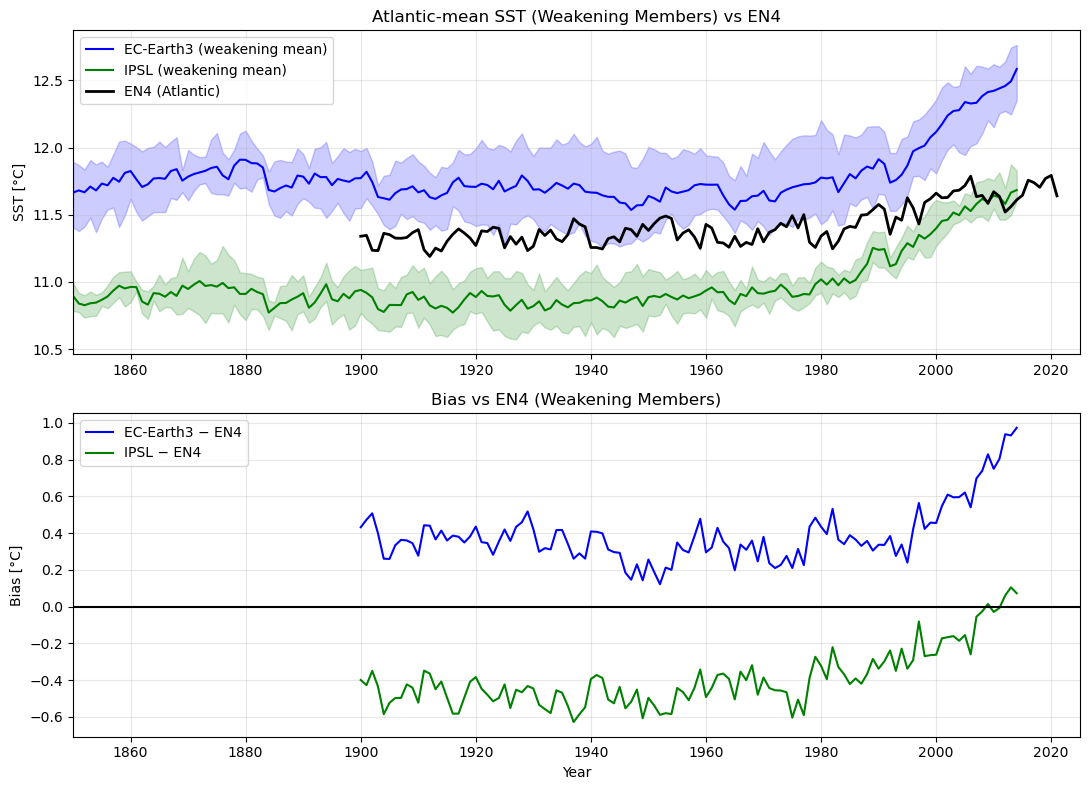

In [14]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt

# ======================================================
# PATHS
# ======================================================
EN4_FILE = "/data/projects/nckf/frekle/obs_data/EN4_SST_Atlantic_masked.nc"

EC_PATTERN   = "/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/thetao/thetao_masked_r*i1p1f1.nc"
IPSL_PATTERN = "/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/thetao/thetao_masked_r*i1p1f1.nc"

FULL_YEARS = np.arange(1850, 2026)

EC_WEAK = [
    "r11i1p1f1",
    "r19i1p1f1",
    "r1i1p1f1",
    "r24i1p1f1",
    "r7i1p1f1",
    "r8i1p1f1"
]

IPSL_WEAK = [
    "r11i1p1f1",
    "r13i1p1f1",
    "r16i1p1f1",
    "r20i1p1f1",
    "r27i1p1f1",
    "r6i1p1f1",
    "r8i1p1f1"
]

# ======================================================
# Helper to load weakening members
# ======================================================
def load_weakening(pattern, weak_ids, name):
    files = sorted(glob.glob(pattern))
    files = [f for f in files if any(w in f for w in weak_ids)]
    print(f"{name}: found {len(files)} weakening members")

    ts_list = []

    for f in files:
        print("  ->", f)
        ds = xr.open_dataset(f)

        da3d = ds["thetao"]
        depth_dim = [d for d in da3d.dims if d in ["lev","olevel","depth","z_t"]][0]

        sst = da3d.isel({depth_dim: 0})

        # convert from Kelvin if needed
        if float(sst.mean()) > 150:
            sst = sst - 273.15

        # spatial mean
        space_dims = [d for d in sst.dims if d != "time"]
        ts = sst.mean(dim=space_dims, skipna=True)

        # yearly mean
        years = ts["time"].dt.year
        ts_year = ts.groupby(years).mean()

        if "time" in ts_year.dims:
            ts_year = ts_year.rename({"time": "year"})

        ts_year = ts_year.assign_coords(year=("year", np.unique(years.values)))

        ts_list.append(ts_year)
        ds.close()

    da = xr.concat(ts_list, dim="member")
    da = da.assign_coords(member=np.arange(1, len(ts_list)+1))

    return da.reindex(year=FULL_YEARS)

# ======================================================
# EN4 reference
# ======================================================
en4 = xr.open_dataset(EN4_FILE)["sst"]
if "time" in en4.dims:
    en4 = en4.rename({"time": "year"})

space_dims = [d for d in en4.dims if d != "year"]
en4_mean = en4.mean(dim=space_dims, skipna=True).reindex(year=FULL_YEARS)

if float(en4_mean.mean()) > 150:
    en4_mean = en4_mean - 273.15

# ======================================================
# Load weakening members
# ======================================================
ec_w = load_weakening(EC_PATTERN, EC_WEAK, "EC-Earth3")
ipsl_w = load_weakening(IPSL_PATTERN, IPSL_WEAK, "IPSL")

# ensemble statistics
def ensemble_stats(da):
    mean = da.mean("member")
    p10  = da.quantile(0.10, dim="member")
    p90  = da.quantile(0.90, dim="member")
    return mean, p10, p90

ec_mean, ec_p10, ec_p90 = ensemble_stats(ec_w)
ipsl_mean, ipsl_p10, ipsl_p90 = ensemble_stats(ipsl_w)

# ======================================================
# Bias = (model − EN4)
# ======================================================
valid = ~np.isnan(en4_mean)
years_bias = en4_mean.year[valid]

ec_bias = ec_mean.sel(year=years_bias) - en4_mean.sel(year=years_bias)
ipsl_bias = ipsl_mean.sel(year=years_bias) - en4_mean.sel(year=years_bias)

# ======================================================
# PLOT
# ======================================================
plt.figure(figsize=(11, 8))

# ---------- (1) Time evolution ----------
ax1 = plt.subplot(2,1,1)

# EC-Earth3
ax1.fill_between(FULL_YEARS, ec_p10, ec_p90, alpha=0.2, color="blue")
ax1.plot(FULL_YEARS, ec_mean, label="EC-Earth3 (weakening mean)", color="blue")

# IPSL
ax1.fill_between(FULL_YEARS, ipsl_p10, ipsl_p90, alpha=0.2, color="green")
ax1.plot(FULL_YEARS, ipsl_mean, label="IPSL (weakening mean)", color="green")

# EN4
ax1.plot(FULL_YEARS, en4_mean, color="black", lw=2, label="EN4 (Atlantic)")

ax1.set_xlim(1850, 2025)
ax1.set_ylabel("SST [°C]")
ax1.set_title("Atlantic-mean SST (Weakening Members) vs EN4")
ax1.grid(True, alpha=0.3)
ax1.legend()

# ---------- (2) Bias ----------
ax2 = plt.subplot(2,1,2, sharex=ax1)

ax2.plot(years_bias, ec_bias, label="EC-Earth3 − EN4", color="blue")
ax2.plot(years_bias, ipsl_bias, label="IPSL − EN4", color="green")

ax2.axhline(0, color="k")
ax2.set_xlim(1850, 2025)
ax2.set_ylabel("Bias [°C]")
ax2.set_xlabel("Year")
ax2.set_title("Bias vs EN4 (Weakening Members)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


In [10]:
import xarray as xr
f = "/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/masked/thetao_masked_r1i1p1f1.nc"
ds = xr.open_dataset(f)
print(ds["lev"].values[:20])
print(ds["lev"].attrs)


[  500.          1500.          2500.          3500.
  4500.          5500.          6500.          7500.
  8500.          9500.         10500.         11500.
 12500.         13500.         14500.         15500.
 16509.83984375 17547.90429688 18629.12695312 19766.02734375]
{'units': 'centimeters', 'positive': 'down', 'axis': 'Z', 'bounds': 'lev_bnds', 'standard_name': 'olevel', 'title': 'ocean model level', 'type': 'double'}
